 LINEAR REGRESSION MODEL TO TRACK STUDENT PERFORMANCE

In [28]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

performance = pd.read_csv('Student_Performance.csv')
performance

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [29]:
performance.head(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


In [30]:
#SETTING A NAME FO THE INDEX

performance.index.name='Student_No'
performance


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Student_No,,,,,,
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0


In [ ]:
print(performance.isnull().sum(),'\n')         # count missing per column
print(df.isnull().mean() * 100)                # % missing per column

# IF MORE THAT 50% OF THE VALUES ARE MISSING YOU CAN CHOOSE TO DROP THE COLUMN BUT IF IT IS NUMERICAL YOU CAN FILL IT USING A SPECIFIC VALUE

# CHECKING THE NUMBER OF DUPLICATES IN THE DATASET
print("THE NUMBER OF DUPLICATE RECORDS IS: ", performance.duplicated().sum())


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64 

THE NUMBER OF DUPLICATE RECORDS IS:  127


In [32]:

# REMOVE THE DUPLICATE RECORDS

performance = performance.drop_duplicates()
performance

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Student_No,,,,,,
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0


In [34]:
performance.info()
print("\n")
performance.describe()

<class 'pandas.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   str    
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(4), str(1)
memory usage: 539.9 KB




,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,9873.000000,9873.000000,9873.000000,9873.000000,9873.000000
mean,4.992100,69.441102,6.531652,4.583004,55.216651
std,2.589081,17.325601,1.697683,2.867202,19.208570
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


ANALYTICAL GRAPHS FOR EACH FEATURE

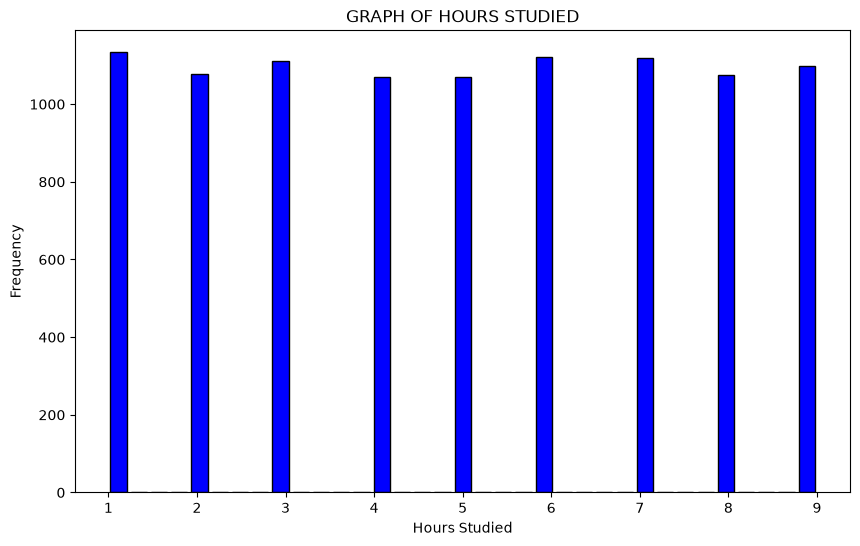

In [82]:
fig =px.histogram(
    performance,
    x='Hours Studied',
    marginal='box',
    color_discrete_sequence= ['blue'],
    nbins = 25,
    title = 'GRAPH OF HOURS STUDIED'
)

fig.update_layout(bargap=0)
fig.show()

# USING PYPLOT
plt.figure(figsize=(10, 6))
plt.hist(
    performance['Hours Studied'],
    bins=35,
    color='blue',
    edgecolor='black',
    rwidth=0.8
)

plt.title('GRAPH OF HOURS STUDIED')
plt.xlabel('Hours Studied')
plt.ylabel('Frequency')

plt.show()


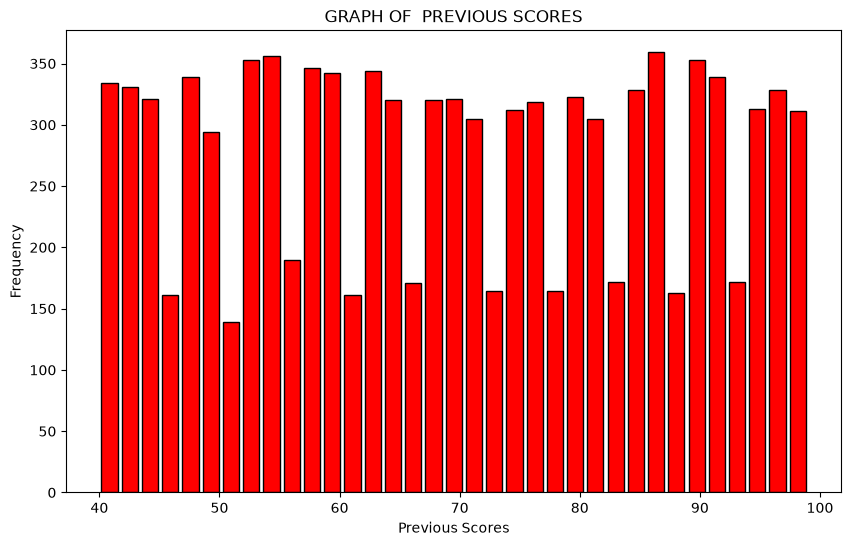

In [81]:
fig =px.histogram(
    performance,
    x='Previous Scores',
    marginal='box',
    color_discrete_sequence= ['red'],
    nbins = 35,
    title = 'GRAPH OF PREVIOUS SCORES'
)

fig.update_layout(bargap=0.1)
fig.show()

# USING PYPLOT
plt.figure(figsize=(10, 6))
plt.hist(
    performance['Previous Scores'],
    bins=35,
    color='red',
    edgecolor='black',
    rwidth=0.8
)

plt.title('GRAPH OF  PREVIOUS SCORES')
plt.xlabel('Previous Scores')
plt.ylabel('Frequency')

plt.show()


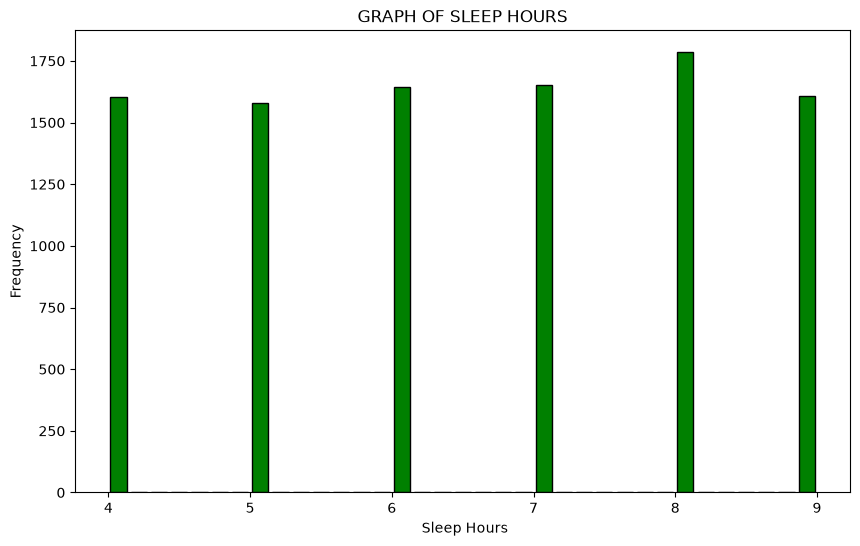

In [77]:
fig =px.histogram(
    performance,
    x='Sleep Hours',
    marginal='box',
    color_discrete_sequence= ['green'],
    nbins = 25,
    title = 'GRAPH OF SLEEP HOURS'
)

fig.update_layout(bargap=0)
fig.show()

# USING PYPLOT
plt.figure(figsize=(10, 6))
plt.hist(
    performance['Sleep Hours'],
    bins=35,
    color='green',
    edgecolor='black',
    rwidth=0.8
)

plt.title('GRAPH OF SLEEP HOURS')
plt.xlabel(' Sleep Hours')
plt.ylabel('Frequency')

plt.show()


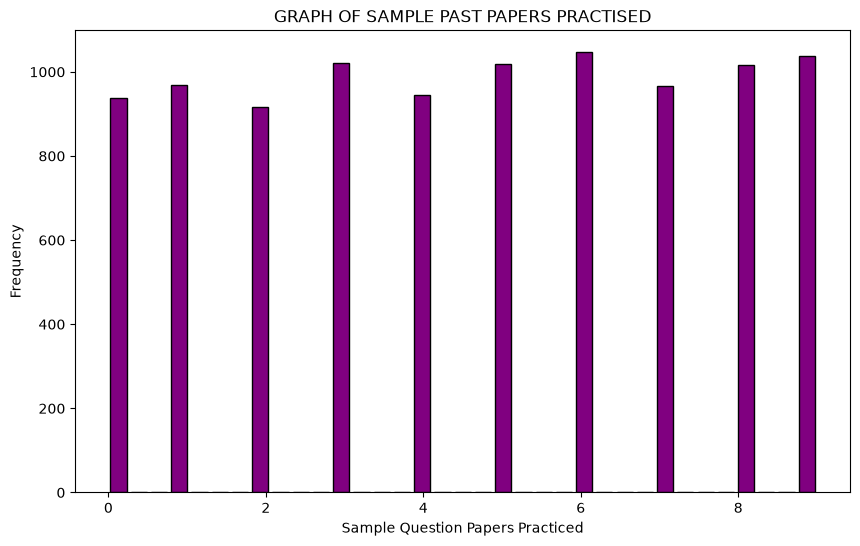

In [78]:
fig =px.histogram(
    performance,
    x='Sample Question Papers Practiced',
    marginal='box',
    color_discrete_sequence= ['purple'],
    nbins = 35,
    title = 'GRAPH OF SAMPLE PAST PAPERS PRACTISED'
)

fig.update_layout(bargap=0)
fig.show()


# USING PYPLOT
plt.figure(figsize=(10, 6))
plt.hist(
    performance['Sample Question Papers Practiced'],
    bins=35,
    color='purple',
    edgecolor='black',
    rwidth=0.8
)

plt.title('GRAPH OF SAMPLE PAST PAPERS PRACTISED')
plt.xlabel('Sample Question Papers Practiced')
plt.ylabel('Frequency')

plt.show()




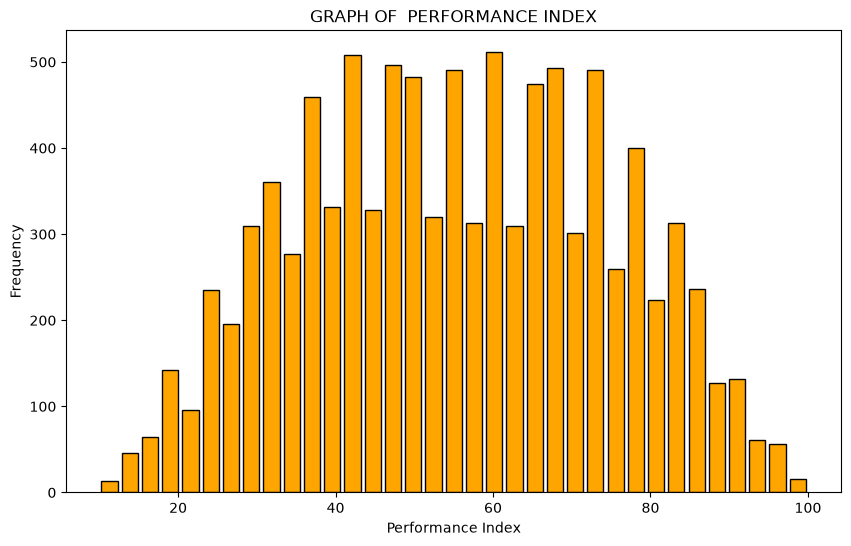

In [79]:
fig =px.histogram(
    performance,
    x='Performance Index',
    marginal='box',
    color_discrete_sequence= ['orange'],
    nbins = 35,
    title = 'GRAPH OF SAMPLE PAST PAPERS PRACTISED'
)

fig.update_layout(bargap=0.2)
fig.show()

print("\n")

# USING PYPLOT  
plt.figure(figsize=(10, 6))
plt.hist(
    performance['Performance Index'],
    bins=35,
    color='orange',
    edgecolor='black',
    rwidth=0.8
)

plt.title('GRAPH OF  PERFORMANCE INDEX')
plt.xlabel('Performance Index')
plt.ylabel('Frequency')

plt.show()


